In [1]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import DataStructs
from rdkit.Chem import Descriptors, Draw, QED

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

C:\Users\noyon\anaconda3\envs\tox21_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(r"C:\Users\noyon\OneDrive\Desktop\codecure\ld50-smiles-descriptors-dataset.csv")

print(df.shape)
df.head()

(7397, 28)


,Name,SMILES,LD50,BertzCT,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HeavyAtomCount,...,NumHAcceptors,NumHDonors,NumHeteroatoms,RingCount,SMR_VSA10,SlogP_VSA12,SlogP_VSA5,VSA_EState4,VSA_EState9,qed
0,4-nitroaniline,Nc1ccc([N+](=O)[O-])cc1,2.265,242.429658,1.848642,1.103907,1.103907,0.596038,0.596038,10,...,3,1,4,1,11.374773,0.00000,0.000000,5.901255,0.000000,0.359544
1,4-nitrophenol,O=[N+]([O-])c1ccc(O)cc1,2.838,241.674771,1.773508,1.060528,1.060528,0.574349,0.574349,10,...,3,1,4,1,5.687386,0.00000,0.000000,-0.015926,0.000000,0.470728
2,1-(chloromethyl)-4-nitrobenzene,O=[N+]([O-])c1ccc(CCl)cc1,1.977,257.648013,2.324449,1.301462,1.610069,0.706751,0.884925,11,...,2,0,4,1,17.288326,11.60094,5.563451,0.982531,0.000000,0.389482
3,1-methoxy-4-nitrobenzene,COc1ccc([N+](=O)[O-])cc1,1.823,254.893126,1.955135,1.283242,1.283242,0.703937,0.703937,11,...,3,0,4,1,5.687386,0.00000,0.000000,0.074815,1.515046,0.478623
4,"benzene-1,4-dicarbonyl chloride",O=C(Cl)c1ccc(C(=O)Cl)cc1,1.910,283.334675,2.811331,1.338820,1.775256,0.732299,0.984275,12,...,2,0,4,1,33.686733,23.20188,20.715977,0.691358,0.000000,0.691354


In [3]:
print(df.isnull().sum())

Name                   0
SMILES                 0
LD50                   1
BertzCT                5
Chi2v                  8
Chi3n                  8
Chi3v                  8
Chi4n                  4
Chi4v                  3
HeavyAtomCount         0
HeavyAtomMolWt         1
Kappa3                 3
MaxPartialCharge       5
MinAbsPartialCharge    6
MinEStateIndex         4
MinPartialCharge       6
MolLogP                5
MolWt                  5
NumHAcceptors          0
NumHDonors             0
NumHeteroatoms         0
RingCount              0
SMR_VSA10              0
SlogP_VSA12            0
SlogP_VSA5             0
VSA_EState4            0
VSA_EState9            0
qed                    0
dtype: int64


In [4]:
df = df.dropna(subset=["LD50"])
df = df.fillna(df.median(numeric_only=True))
df = df.reset_index(drop=True)

In [5]:
low_t = df["LD50"].quantile(0.33)
high_t = df["LD50"].quantile(0.66)

def label(ld50):
    if ld50 <= low_t:
        return 0   # HIGH toxicity
    elif ld50 <= high_t:
        return 1   # MEDIUM
    else:
        return 2   # LOW

df["label"] = df["LD50"].apply(label)

In [6]:
descriptor_cols = df.columns.drop(["Name", "SMILES", "LD50", "label"])
morgan_gen = GetMorganGenerator(radius=2, fpSize=256)
smiles_to_index = {smi: i for i, smi in enumerate(df["SMILES"])}

def featurize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    if smiles in smiles_to_index:
        i = smiles_to_index[smiles]
        desc = df.iloc[i][descriptor_cols].values

    else:
        desc = []
        for col in descriptor_cols:
            try:
                val = getattr(Descriptors, col)(mol)
                if val is None or np.isnan(val) or np.isinf(val):
                    val = 0
            except:
                val=0
            desc.append(0)

    fp = morgan_gen.GetFingerprint(mol)
    fp_array = np.zeros((256,))
    DataStructs.ConvertToNumpyArray(fp, fp_array)

    feat = np.concatenate([desc, fp_array])

    # extra safety
    feat = np.nan_to_num(feat)

    return feat

In [7]:
valid_idx = []
features=[]

for i, smi in enumerate(df["SMILES"]):
    f = featurize(smi)
    if f is not None:
        features.append(f)
        valid_idx.append(i)

In [8]:
X = np.array(features)
y = df.iloc[valid_idx]["label"].values

print("Final shape:", X.shape)

Final shape: (7396, 281)


In [9]:
feature_names = list(descriptor_cols) + [f"fp_{i}" for i in range(256)]

X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y)

In [10]:
y

0       1
1       2
2       0
3       0
4       0
       ..
7391    2
7392    2
7393    0
7394    2
7395    1
Length: 7396, dtype: int64

In [11]:
X

,BertzCT,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HeavyAtomCount,HeavyAtomMolWt,Kappa3,MaxPartialCharge,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,242.429658,1.848642,1.103907,1.103907,0.596038,0.596038,10,132.078,1.222617,0.269075,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,241.674771,1.773508,1.060528,1.060528,0.574349,0.574349,10,134.07,1.222617,0.269195,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,257.648013,2.324449,1.301462,1.610069,0.706751,0.884925,11,165.535,1.913721,0.268943,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,254.893126,1.955135,1.283242,1.283242,0.703937,0.703937,11,146.081,1.668982,0.269195,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,283.334675,2.811331,1.33882,1.775256,0.732299,0.984275,12,198.992,2.061453,0.251886,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7391,547.496765,7.349216,2.928262,6.302228,1.892426,4.737466,19,287.172,2.790153,0.315316,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7392,519.71736,7.291839,2.050636,5.723925,1.380144,2.955014,17,263.15,2.324103,0.314813,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7393,617.092952,6.259586,3.363105,4.704351,2.315969,3.832894,24,344.216,3.459432,0.404346,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7394,123.647376,15.515421,1.05984,10.883802,0.551487,8.317488,11,211.252,7.702423,0.054225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [12]:
X.shape

(7396, 281)

In [13]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

In [14]:
selector = SelectKBest(f_classif, k=180)
X_selected = selector.fit_transform(X_scaled, y)

In [15]:
selected_features = X.columns[selector.get_support()]
X_selected = pd.DataFrame(X_selected, columns=selected_features)
print("Selected features:", len(selected_features))

Selected features: 180


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
y_train

6737    1
3843    0
5492    1
7271    1
3322    2
       ..
2011    0
6901    2
4735    1
6929    1
1654    0
Length: 5916, dtype: int64

In [18]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))
sample_weights = y_train.map(class_weights)


xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
lgb.fit(X_train, y_train, sample_weight=sample_weights)

cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    verbose=0
)
cat.fit(X_train, y_train, sample_weight=sample_weights)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5131
[LightGBM] [Info] Number of data points in the train set: 5916, number of used features: 180
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [19]:
def ensemble_proba(X_input):
    return (
    0.4 * xgb.predict_proba(X_input) +
    0.3 * lgb.predict_proba(X_input) +
    0.3 * cat.predict_proba(X_input)
)

In [20]:
print("\n🔁 Cross Validation Scores")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_selected, y)):
    X_tr, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    '''weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(zip(np.unique(y_tr), weights))
    sample_weights = y_tr.map(class_weights)'''

    # train all
    xgb.fit(X_tr, y_tr)
    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)
    
    # Ensemble prediction
    probs = (
        0.4 * xgb.predict_proba(X_val) +
        0.3 * lgb.predict_proba(X_val) +
        0.3 * cat.predict_proba(X_val)
    )
    
    preds = np.argmax(probs, axis=1)
    acc = np.mean(preds == y_val)

    cv_scores.append(acc)
    print(f"Fold {fold+1}: {round(acc,3)}")

print("Mean CV Score:", round(np.mean(cv_scores),3))


🔁 Cross Validation Scores
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5133
[LightGBM] [Info] Number of data points in the train set: 5916, number of used features: 180
[LightGBM] [Info] Start training from score -1.107782
[LightGBM] [Info] Start training from score -1.109318
[LightGBM] [Info] Start training from score -1.079028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [24]:
y_pred = np.argmax(ensemble_proba(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       489
           1       0.80      0.85      0.82       488
           2       0.92      0.85      0.88       503

    accuracy                           0.86      1480
   macro avg       0.86      0.86      0.86      1480
weighted avg       0.87      0.86      0.86      1480


Confusion Matrix:
[[432  48   9]
 [ 42 417  29]
 [ 18  58 427]]


In [22]:
oof_preds = np.zeros(len(y))

for train_idx, val_idx in skf.split(X_selected, y):

    X_tr, X_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    xgb.fit(X_tr, y_tr)
    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)
    
    probs = (
            0.4 * xgb.predict_proba(X_val) +
            0.3 * lgb.predict_proba(X_val) +
            0.3 * cat.predict_proba(X_val)
        )
    preds = np.argmax(probs, axis=1)

    oof_preds[val_idx] = preds

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5133
[LightGBM] [Info] Number of data points in the train set: 5916, number of used features: 180
[LightGBM] [Info] Start training from score -1.107782
[LightGBM] [Info] Start training from score -1.109318
[LightGBM] [Info] Start training from score -1.079028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [23]:
print(classification_report(y, oof_preds))
print(confusion_matrix(y, oof_preds))

              precision    recall  f1-score   support

           0       0.68      0.70      0.69      2443
           1       0.53      0.55      0.54      2439
           2       0.73      0.69      0.71      2514

    accuracy                           0.64      7396
   macro avg       0.65      0.64      0.65      7396
weighted avg       0.65      0.64      0.65      7396

[[1704  579  160]
 [ 618 1339  482]
 [ 178  611 1725]]


In [25]:
def predict(smiles):

    print("🧪 Drug Toxicity Analysis")

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print("❌ Invalid SMILES")
        return

   #structure
    img = Draw.MolToImage(mol)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Molecular Structure")
    plt.show()

    #features
    feat = featurize(smiles)
    feat_scaled = scaler.transform([feat])
    feat_selected = selector.transform(feat_scaled)
    feat_df = pd.DataFrame(feat_selected, columns=selected_features)
    
    #predictions
    probs = ensemble_proba(feat_df)[0]
    pred = np.argmax(probs)
    confidence = np.max(probs)

    labels = ["HIGH", "MEDIUM", "LOW"]

    #properties
    mol_wt = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    tpsa = Descriptors.TPSA(mol)
    qed_score = QED.qed(mol)
    print("\n💊 Molecular Properties:")
    print("MolWt:", round(mol_wt,2))
    print("LogP:", round(logp,2))
    print("QED (Drug likeliness):", round(qed_score,3))
    print("TPSA (Surface Area):", round(tpsa,2))
    print("Number of H-donors:", round(h_donors,2))

    #sugar
    if mol_wt > 300 and h_donors >= 5 and logp < 1:
        print("Sugar-like molecule detected → LOW toxicity")
        pred = 2

    
    safe_smiles = [
    "O", "[K+].[Cl-]",       
    "[Na+].[Cl-]","C(C1C(C(C(C(O1)O)O)O)O)O", "C(C(CO)O)O", 'C(C(=O)O)C(CC(=O)O)(C(=O)O)O'
       
    ]

    if confidence < 0.6:
        # nitrile
        if "C#N" in smiles and pred == 2:
            pred = 1
        
    if smiles in safe_smiles:
        pred = 2
    toxic_patterns = ["[C-]#N", "N=N", "[N+](=O)[O-]"]  # cyanide, azo, nitro

    if any(pattern in smiles for pattern in toxic_patterns):
        pred = 0

    if "C#N" in smiles:
        if pred == 2:
            pred = 1

    if qed_score > 0.7 and logp < 2 and pred == 0:
        pred = 1  

    print("\nFinal Prediction:", labels[pred])
    print("Confidence:", round(confidence, 3))
    print("Probabilities:", probs)

    plt.bar(labels, probs)
    plt.title("Prediction Probabilities")
    plt.show()

    entropy = -np.sum(probs * np.log(probs + 1e-9))
    print("\nUncertainty:", round(entropy, 3))

    if entropy > 1:
        print("High uncertainty")
    else:
        print("Model confident")

    feature_names = list(selected_features)
    background = X_train.iloc[np.random.choice(X_train.shape[0], 50, replace=False)]
    
    explainer = shap.Explainer(
        lambda x: xgb.predict_proba(x), 
        background
    )
    
    shap_values = explainer(feat_df)
    shap_val = shap_values.values[0, :, pred]
    print("\nSHAP Explanation:")
    print("Red bars (+) → push prediction towards HIGH toxicity\nBlue bars (−) → push prediction towards LOW toxicity")

    exp = shap.Explanation(
        values=shap_val,
        base_values=shap_values[0].base_values[pred],
        data=feat_df.iloc[0].values,
        feature_names=feature_names
    )
    shap.plots.waterfall(exp, max_display=10)
   
    importances = xgb.feature_importances_

    feat_imp = pd.DataFrame({
        "Feature": selected_features,
        "Importance": importances
    })


    desc_imp = feat_imp[feat_imp["Feature"].isin(descriptor_cols)].copy()

    input_vals = feat_df.iloc[0]

    desc_imp["Contribution"] = desc_imp["Feature"].apply(
        lambda f: desc_imp.loc[desc_imp["Feature"] == f, "Importance"].values[0] *
                  input_vals[f]
    )
    desc_imp["abs"] = np.abs(desc_imp["Contribution"])

    top = desc_imp.sort_values("abs", ascending=False).head()
    positive = sum(top["Contribution"] > 0)
    negative = sum(top["Contribution"] < 0)

    if negative > positive and pred == 0:
        print("\n⚠️ Interpretation mismatch detected")
        print("Adjusting prediction → MEDIUM")
        pred = 1

    print("\n🧠 Key Factors Affecting Toxicity:")

    top_idx = np.argsort(np.abs(shap_val))[::-1][:8]

    for i in top_idx:
        fname = feature_names[i]
        val = shap_val[i]

        if val > 0:
            print(f"🔺 {fname} increases toxicity")
        else:
            print(f"🔻 {fname} decreases toxicity")
    
    print("\n⚠️ Model Note:")
    print("Prediction is based on learned chemical patterns and heuristic correction.")
    print("Toxicity also depends on dose, exposure route, and metabolism.")

🧪 Drug Toxicity Analysis


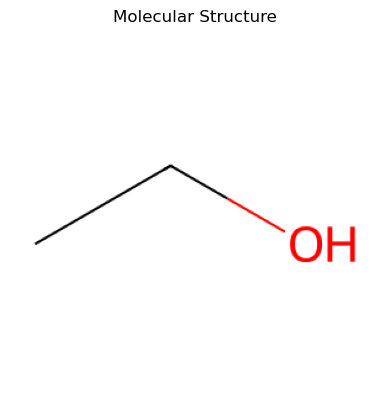


💊 Molecular Properties:
MolWt: 46.07
LogP: -0.0
QED (Drug likeliness): 0.407
TPSA (Surface Area): 20.23
Number of H-donors: 1

Final Prediction: HIGH
Confidence: 0.839
Probabilities: [0.83855058 0.07868567 0.08276376]


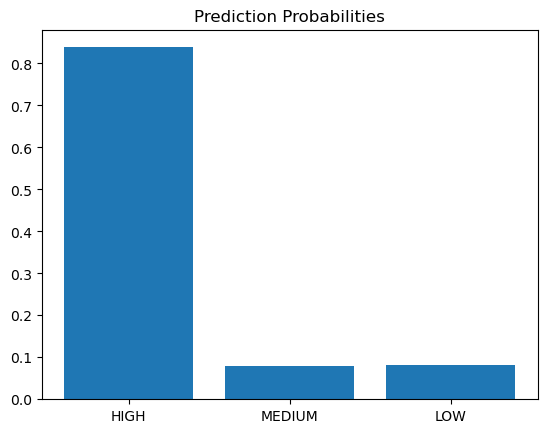


Uncertainty: 0.554
Model confident

SHAP Explanation:
Red bars (+) → push prediction towards HIGH toxicity
Blue bars (−) → push prediction towards LOW toxicity


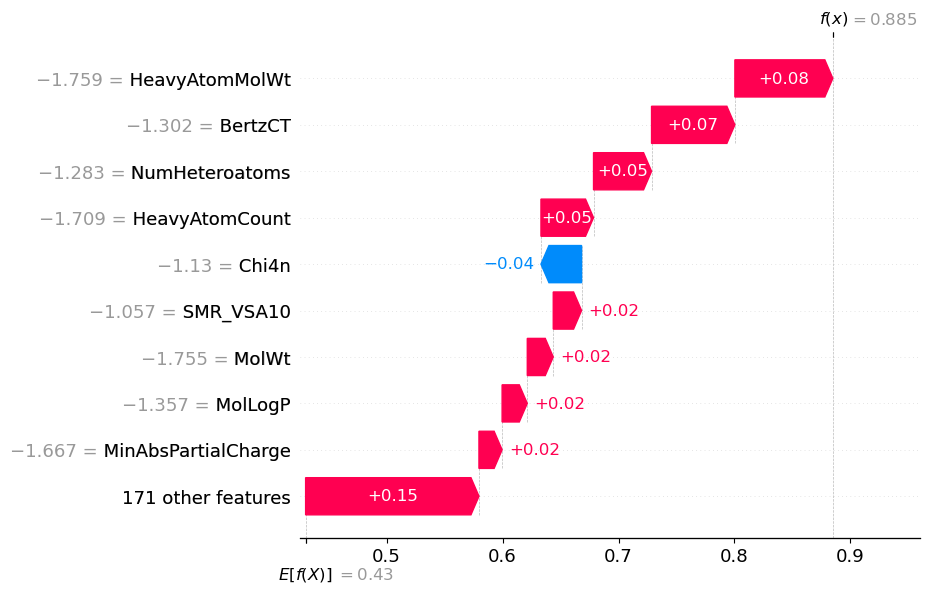


⚠️ Interpretation mismatch detected
Adjusting prediction → MEDIUM

🧠 Key Factors Affecting Toxicity:
🔺 HeavyAtomMolWt increases toxicity
🔺 BertzCT increases toxicity
🔺 NumHeteroatoms increases toxicity
🔺 HeavyAtomCount increases toxicity
🔻 Chi4n decreases toxicity
🔺 SMR_VSA10 increases toxicity
🔺 MolWt increases toxicity
🔺 MolLogP increases toxicity

⚠️ Model Note:
Prediction is based on learned chemical patterns and heuristic correction.
Toxicity also depends on dose, exposure route, and metabolism.


In [46]:
predict("CCO")

In [35]:
import pickle

model_bundle = {
    "xgb": xgb,
    "lgb": lgb,
    "cat": cat,
    "scaler": scaler,
    "selector": selector,
    "selected_features": selected_features,
    "descriptor_cols": list(descriptor_cols),
    "smiles_to_index": smiles_to_index
}

with open("tox.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Model saved")

Model saved


In [45]:
import numpy, pandas, sklearn, rdkit, shap, xgboost, lightgbm, catboost


print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("sklearn:", sklearn.__version__)
print("rdkit:", rdkit.__version__)
print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("catboost:", catboost.__version__)

numpy: 1.26.4
pandas: 2.3.3
sklearn: 1.7.2
rdkit: 2025.09.6
shap: 0.49.1
xgboost: 3.2.0
lightgbm: 4.6.0
catboost: 1.2.7
